In [1]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded")

Libraries loaded


In [3]:
# Cell 3: Load the CSV files
BASE_PATH = '/content/drive/MyDrive/EGR432/midterm_project/data/'

print("Loading Monday (benign)...")
df_monday = pd.read_csv(BASE_PATH + 'Monday-WorkingHours.pcap_ISCX.csv')

print("Loading Wednesday (DoS)...")
df_wednesday = pd.read_csv(BASE_PATH + 'Wednesday-workingHours.pcap_ISCX.csv')

print("Loading Friday DDoS...")
df_friday = pd.read_csv(BASE_PATH + 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

print("All files loaded")

Loading Monday (benign)...
Loading Wednesday (DoS)...
Loading Friday DDoS...
All files loaded


In [5]:
# Cell 4: Combine into one DataFrame
df = pd.concat([df_monday, df_wednesday, df_friday], ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print("\nLabel distribution:")
print(df[' Label'].value_counts())

Total rows: 1,448,366
Total Columns: 79

Label distribution:
 Label
BENIGN              1067667
DoS Hulk             231073
DDoS                 128027
DoS GoldenEye         10293
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64


In [6]:
# Cell 5: Clean the data

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Drop Heartbleed
df = df[df['Label'] != 'Heartbleed']
print (f"Rows after dropping Heartbleed: {len(df):,}")

# Create binary label - BENIGN=0, any attack=1
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)
print("\nBinary label distribution:")
print(df['binary_label'].value_counts())
print(f"Attack rate: {df['binary_label'].mean():.1%}")

# Replace infinite values with NaN, then drop them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_count = df.isnull().sum().sum()
print(f"\nNan values found: {nan_count:,}")
df.dropna(inplace=True)
print(f"Rows after dropping NaNs: {len(df):,}")

# Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\nDuplicate rows removed: {before - len(df):,}")
print(f"Final clean rows: {len(df):,}")

Rows after dropping Heartbleed: 1,448,355

Binary label distribution:
binary_label
0    1067667
1     380688
Name: count, dtype: int64
Attack rate: 26.3%

Nan values found: 3,536
Rows after dropping NaNs: 1,446,587

Duplicate rows removed: 113,323
Final clean rows: 1,333,264


In [7]:
# Cell 6: Select 15 meaningful features

# These were chose based o
# 1. Domain knowledge
# 2. Known importance in CICIDS2017 literature
# 3. Covering different "angles" of traffic behavior

FEATURES_15 = [
    # Flow volume features — attacks send abnormal amounts of data
    'Flow Bytes/s',           # 1. Bytes transferred per second
    'Flow Packets/s',         # 2. Packets per second (DoS = very high)

    # Packet length features — attack packets are often uniform/tiny
    'Fwd Packet Length Max',  # 3. Largest forward packet
    'Fwd Packet Length Mean', # 4. Average forward packet size
    'Bwd Packet Length Max',  # 5. Largest backward packet
    'Bwd Packet Length Mean', # 6. Average backward packet size

    # Flow timing — DoS floods have very short inter-arrival times
    'Flow IAT Mean',          # 7. Mean inter-arrival time between packets
    'Flow IAT Std',           # 8. Std deviation of inter-arrival time
    'Fwd IAT Total',          # 9. Total time between forward packets

    # TCP flag features — attacks abuse SYN, RST flags
    'SYN Flag Count',         # 10. SYN packets (SYN flood indicator)
    'RST Flag Count',         # 11. RST packets (connection resets)
    'PSH Flag Count',         # 12. PSH flags (data push behavior)

    # Connection behavior
    'Flow Duration',          # 13. How long the flow lasted
    'Total Fwd Packets',      # 14. Packets sent forward
    'Active Mean',            # 15. Mean time flow was active
]

# Verify all features exist in our dataframe
missing = [f for f in FEATURES_15 if f not in df.columns]
if missing:
    print(f"Missing features: {missing}")
else:
    print("All 15 features found!")
    print(f"\nFeature set preview:")
    print(df[FEATURES_15].describe().round(2))

All 15 features found!

Feature set preview:
       Flow Bytes/s  Flow Packets/s  Fwd Packet Length Max  \
count  1.333264e+06      1333264.00             1333264.00   
mean   1.389045e+06        39924.65                 286.94   
std    2.580844e+07       186992.20                 930.90   
min   -1.200000e+07     -2000000.00                   0.00   
25%    1.198200e+02            0.73                  20.00   
50%    2.415360e+03           43.82                  42.00   
75%    3.317052e+04         4750.59                 324.00   
max    2.071000e+09      3000000.00               24820.00   

       Fwd Packet Length Mean  Bwd Packet Length Max  Bwd Packet Length Mean  \
count              1333264.00             1333264.00              1333264.00   
mean                    78.13                1485.87                  501.16   
std                    245.35                2583.85                  790.72   
min                      0.00                   0.00                    0.00

In [8]:
# Cell 7: Remove rows with negative values in physical features

# These columns physically cannot be negative - they're measurement errors
non_negative_cols = ['Flow Bytes/s', 'Flow Packets/s', 'Flow Duration', 'Flow IAT Mean']

before = len(df)
for col in non_negative_cols:
  df = df[df[col] >= 0]

  print(f"Rows removed due to negative values: {before - len(df):,}")
  print(f"Rows remaining: {len(df):,}")

Rows removed due to negative values: 25
Rows remaining: 1,333,239
Rows removed due to negative values: 36
Rows remaining: 1,333,228
Rows removed due to negative values: 36
Rows remaining: 1,333,228
Rows removed due to negative values: 36
Rows remaining: 1,333,228


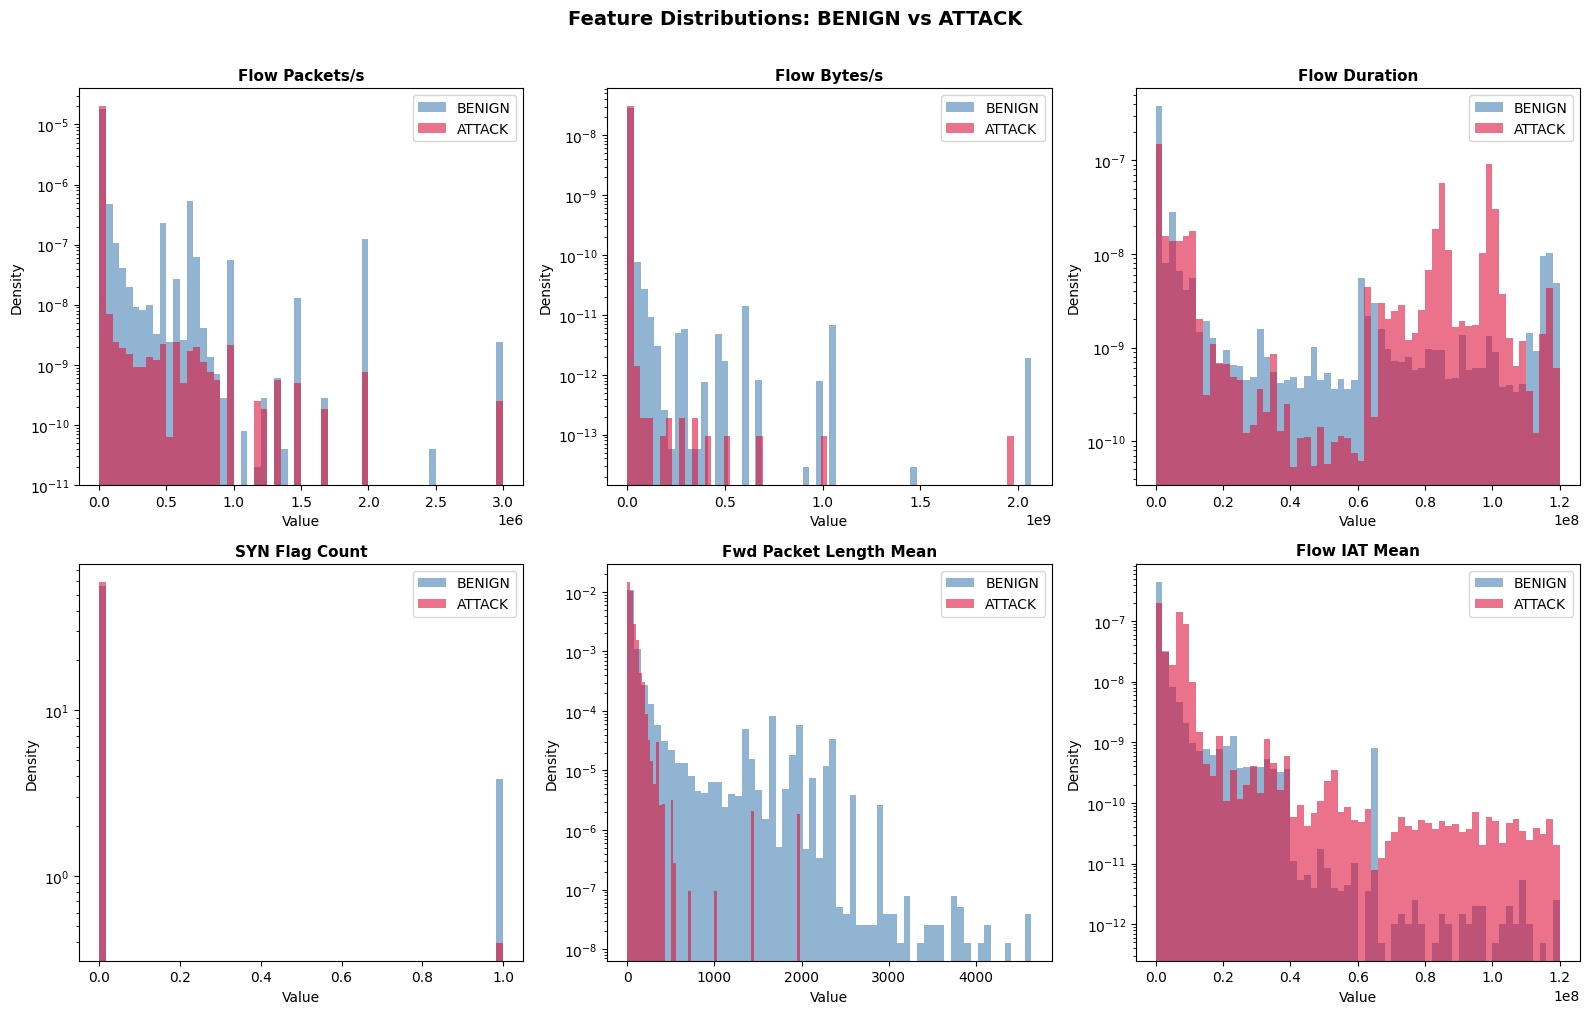

Plot saved


In [9]:
# Cell 8: Visualize feature distributions by label

# Create a readable label column for plotting
df['traffic_type'] = df['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})

# Pick 6 of our most telling features to vizualize
plot_features = [
    'Flow Packets/s',
    'Flow Bytes/s',
    'Flow Duration',
    'SYN Flag Count',
    'Fwd Packet Length Mean',
    'Flow IAT Mean'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(plot_features):
  ax = axes[i]

  benign_vals = df[df['binary_label'] == 0][feature]
  attack_vals = df[df['binary_label'] == 1][feature]

  # Use log scale - the ranges are huge
  ax.hist(benign_vals, bins=60, alpha=0.6, color='steelblue',
          label='BENIGN', density=True)
  ax.hist(attack_vals, bins=60, alpha=0.6, color='crimson',
          label='ATTACK', density=True)

  ax.set_title(feature, fontsize=11, fontweight='bold')
  ax.set_xlabel('Value')
  ax.set_ylabel('Density')
  ax.set_yscale('log')
  ax.legend()

plt.suptitle('Feature Distributions: BENIGN vs ATTACK',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

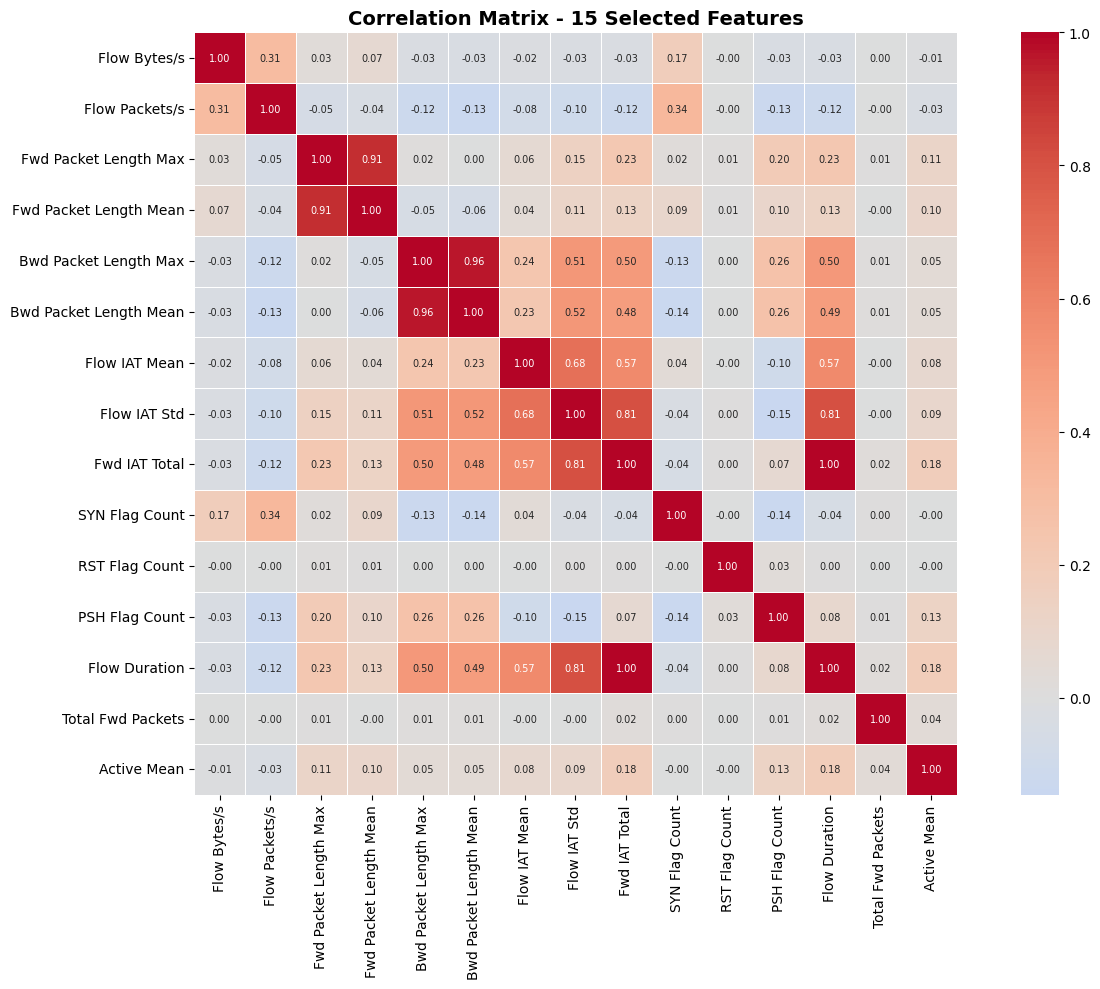

Heatmap saved


In [10]:
# Cell 9: Correlation heatmap
plt.figure(figsize=(14, 10))

corr_matrix = df[FEATURES_15].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Correlation Matrix - 15 Selected Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved")

In [11]:
# Cell 10: Handle high correlation - Drop Fwd IAT total

# Flow Duration and Fwd IAT Total have correlation = 1.00
# Keeping both gives the model redundant signal — drop the less interpretable one

FEATURES_15_FINAL = [
    'Flow Bytes/s',
    'Flow Packets/s',
    'Fwd Packet Length Max',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Bwd Packet Length Mean',
    'Flow IAT Mean',
    'Flow IAT Std',
    # 'Fwd IAT Total' DROPPED: correlation 1.00 with Flow Duration
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'Flow Duration',
    'Total Fwd Packets',
    'Active Mean',
    'Flow Duration',        # keeping as anchor for dropped feature
]

# Actually let's replace Fwd IAT Total with a better feature
# We'll swap in 'Init_Win_bytes_forward' — TCP window size,
# great for detecting DoS (attackers use tiny windows)

# First check if it exists
replacement = 'Init_Win_bytes_forward'
if replacement in df.columns:
    print(f"'{replacement}' found — using as replacement")
else:
    # Check similar names
    win_cols = [c for c in df.columns if 'win' in c.lower() or 'Win' in c]
    print(f"Window-related columns available: {win_cols}")

'Init_Win_bytes_forward' found — using as replacement


In [12]:
# Cell 10b: Finalize the feature list

FEATURES_FINAL = [
    'Flow Bytes/s',
    'Flow Packets/s',
    'Fwd Packet Length Max',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Bwd Packet Length Mean',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'Flow Duration',
    'Total Fwd Packets',
    'Active Mean',
    'Init_Win_bytes_forward',
]

print("Current final feature count:", len(FEATURES_FINAL))
print("\nFeatures:")
for i, f in enumerate(FEATURES_FINAL, 1):
    print(f"  {i:2}. {f}")

Current final feature count: 15

Features:
   1. Flow Bytes/s
   2. Flow Packets/s
   3. Fwd Packet Length Max
   4. Fwd Packet Length Mean
   5. Bwd Packet Length Max
   6. Bwd Packet Length Mean
   7. Flow IAT Mean
   8. Flow IAT Std
   9. SYN Flag Count
  10. RST Flag Count
  11. PSH Flag Count
  12. Flow Duration
  13. Total Fwd Packets
  14. Active Mean
  15. Init_Win_bytes_forward


In [13]:
#  Cell 11: Scale features
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Seperate features (X) and label (y)
X = df[FEATURES_FINAL].values
Y = df['binary_label'].values

# Split BEFORE scaling - critical rule:
# Never let test data influence the scaler (data leakage)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nAttack rate in train: {Y_train.mean():.1%}")
print(f"Attack rate in test:  {Y_test.mean():.1%}")

# Scale AFTER splitting - fit only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train
X_test_scaled  = scaler.transform(X_test)        # transform only (no fit)

print("\nData split and scaled!")
print(f"Example — Flow Bytes/s before scaling: mean={X_train[:,0].mean():.1f}")
print(f"Example — Flow Bytes/s after scaling:  mean={X_train_scaled[:,0].mean():.4f}")

Training set:  1,066,582 rows
Test set:      266,646 rows

Attack rate in train: 24.1%
Attack rate in test:  24.1%

Data split and scaled!
Example — Flow Bytes/s before scaling: mean=1388427.5
Example — Flow Bytes/s after scaling:  mean=0.0000


In [14]:
# Cell 12: Train Random Forest
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf_model.fit(X_train_scaled, Y_train)
elapsed = time.time() - start

print(f"Random Forest trained in {elapsed:.1f} seconds")
print(f"Trees: {rf_model.n_estimators}")
print(f"Features used per split: {rf_model.max_features}")

Training Random Forest...
Random Forest trained in 152.2 seconds
Trees: 100
Features used per split: sqrt


In [15]:
# Cell 13: Train SVM
from sklearn.svm import SVC
import time

# SVM is memory-intensive — we sample 100k rows for training
# This is standard practice for SVM on large datasets
SVM_SAMPLE_SIZE = 100_000

print(f"Sampling {SVM_SAMPLE_SIZE:,} rows for SVM training...")

# Stratified sample — preserve 24.1% attack rate in the sample
from sklearn.utils import resample
X_svm, Y_svm = resample(
    X_train_scaled, Y_train,
    n_samples=SVM_SAMPLE_SIZE,
    stratify=Y_train,
    random_state=42
)

print(f"SVM training sample attack rate: {Y_svm.mean():.1%}")
print(f"\nTraining SVM... (may take 3-5 minutes)\n")

svm_model = SVC(
    kernel='rbf',            # Radial Basis Function — handles non-linear boundaries
    C=1.0,                   # regularization — penalty for misclassification
    gamma='scale',           # auto-scales gamma based on feature variance
    class_weight='balanced', # handles class imbalance
    random_state=42,
    probability=False        # faster without probability estimates
)

start = time.time()
svm_model.fit(X_svm, Y_svm)
elapsed = time.time() - start

print(f"SVM trained in {elapsed:.1f} seconds")
print(f"Kernel: {svm_model.kernel}")
print(f"Support vectors: {svm_model.n_support_}")

Sampling 100,000 rows for SVM training...
SVM training sample attack rate: 24.1%

Training SVM... (may take 3-5 minutes)

SVM trained in 78.8 seconds
Kernel: rbf
Support vectors: [10355  3264]


In [16]:
# Cell 14: Evaluate both models
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score)

def evaluate_model(name, model, X_test, Y_test):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    Y_pred = model.predict(X_test)

    # Core metrics
    acc = accuracy_score(Y_test, Y_pred)
    roc = roc_auc_score(Y_test, Y_pred)

    print(f"\nAccuracy:    {acc:.4f}  ({acc*100:.2f}%)")
    print(f"ROC-AUC:     {roc:.4f}")

    # Precision, Recall, F1 per class
    print(f"\nClassification Report:")
    print(classification_report(Y_test, Y_pred,
                                 target_names=['BENIGN', 'ATTACK']))

    # Confusion matrix
    cm = confusion_matrix(Y_test, Y_pred)
    print(f"Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                 BENIGN    ATTACK")
    print(f"Actual BENIGN  {cm[0][0]:>8,}  {cm[0][1]:>8,}")
    print(f"Actual ATTACK  {cm[1][0]:>8,}  {cm[1][1]:>8,}")

    tn, fp, fn, tp = cm.ravel()
    print(f"\nFalse Positive Rate: {fp/(fp+tn):.4f}  "
          f"(benign flows flagged as attack)")
    print(f"False Negative Rate: {fn/(fn+tp):.4f}  "
          f"(attacks missed entirely)")

    return Y_pred, cm

# Evaluate both on the SAME full test set
rf_preds, rf_cm = evaluate_model("RANDOM FOREST", rf_model,
                                  X_test_scaled, Y_test)
svm_preds, svm_cm = evaluate_model("SVM", svm_model,
                                    X_test_scaled, Y_test)


  RANDOM FOREST

Accuracy:    0.9992  (99.92%)
ROC-AUC:     0.9992

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    202294
      ATTACK       1.00      1.00      1.00     64352

    accuracy                           1.00    266646
   macro avg       1.00      1.00      1.00    266646
weighted avg       1.00      1.00      1.00    266646

Confusion Matrix:
                 Predicted
                 BENIGN    ATTACK
Actual BENIGN   202,153       141
Actual ATTACK        64    64,288

False Positive Rate: 0.0007  (benign flows flagged as attack)
False Negative Rate: 0.0010  (attacks missed entirely)

  SVM

Accuracy:    0.9602  (96.02%)
ROC-AUC:     0.9492

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.98      0.97      0.97    202294
      ATTACK       0.91      0.93      0.92     64352

    accuracy                           0.96    266646
   macro avg    

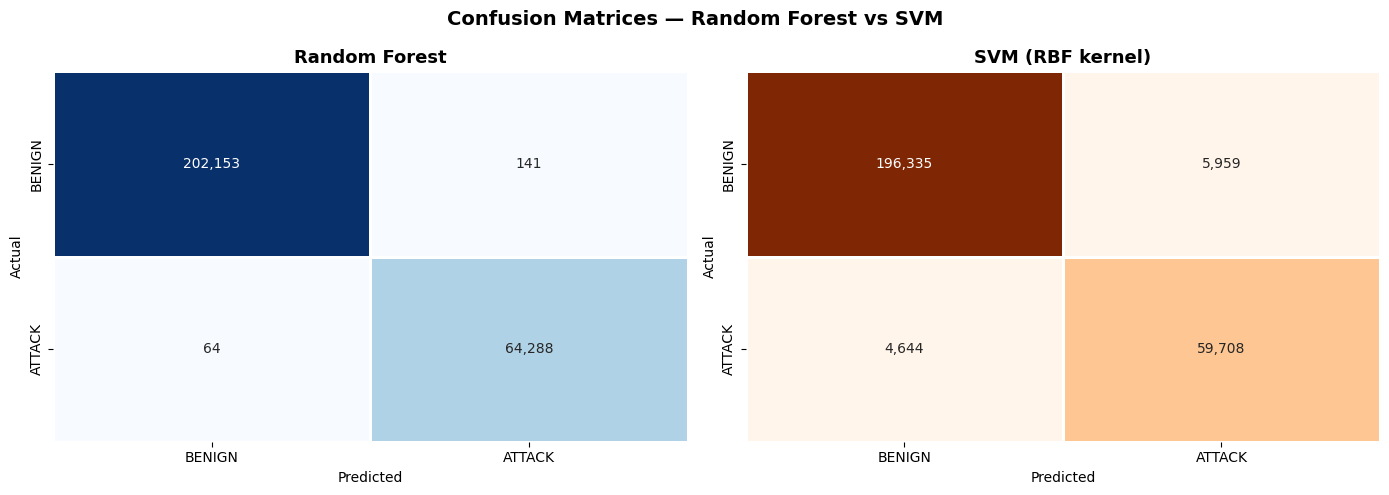

Saved!


In [17]:
# Cell 15: Side-by-side confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, color in zip(
    axes,
    [rf_cm, svm_cm],
    ['Random Forest', 'SVM (RBF kernel)'],
    ['Blues', 'Oranges']
):
    sns.heatmap(
        cm, annot=True, fmt=',', cmap=color,
        xticklabels=['BENIGN', 'ATTACK'],
        yticklabels=['BENIGN', 'ATTACK'],
        ax=ax, cbar=False, linewidths=1
    )
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Random Forest vs SVM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Feature Importance Ranking:
Rank   Feature                        Importnace
------------------------------------------------
1      Bwd Packet Length Mean             0.1989
2      Bwd Packet Length Max              0.1966
3      Total Fwd Packets                  0.1304
4      Flow IAT Std                       0.0797
5      Init_Win_bytes_forward             0.0675
6      Fwd Packet Length Max              0.0642
7      Flow Packets/s                     0.0581
8      Flow IAT Mean                      0.0530
9      Fwd Packet Length Mean             0.0502
10     Flow Duration                      0.0463
11     Active Mean                        0.0240
12     Flow Bytes/s                       0.0225
13     PSH Flag Count                     0.0070
14     SYN Flag Count                     0.0016
15     RST Flag Count                     0.0000


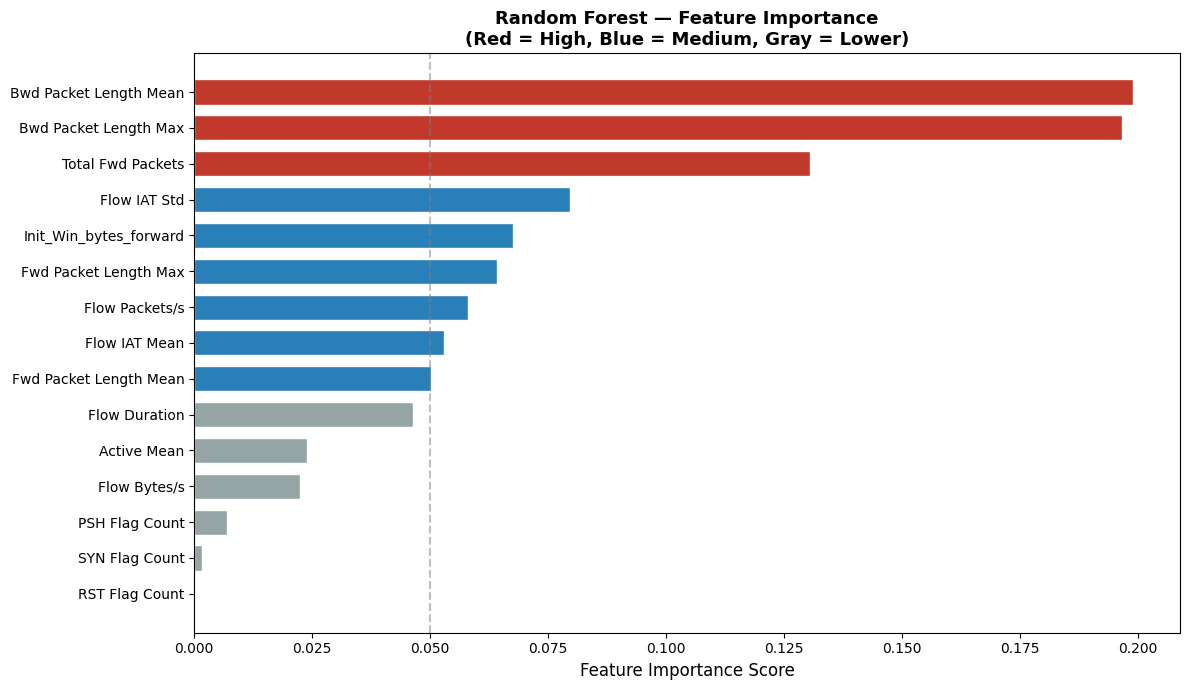

In [19]:
# Cell 16: Feature Importance from Random Forest

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Importance Ranking:")
print(f"{'Rank':<6} {'Feature':<30} {'Importnace':>10}")
print("-" * 48)
for rank, idx in enumerate(indices, 1):
  print(f"{rank:<6} {FEATURES_FINAL[idx]:<30} {importances[idx]:>10.4f}")

# Plot
plt.figure(figsize=(12, 7))
colors = ['#c0392b' if importances[i] > 0.1 else
          '#2980b9' if importances[i] > 0.05 else
          '#95a5a6' for i in indices]

plt.barh(
    [FEATURES_FINAL[i] for i in indices[::-1]],
    importances[indices[::-1]],
    color=colors[::-1],
    edgecolor='white',
    height=0.7
)

plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Random Forest — Feature Importance\n(Red = High, Blue = Medium, Gray = Lower)',
          fontsize=13, fontweight='bold')
plt.axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

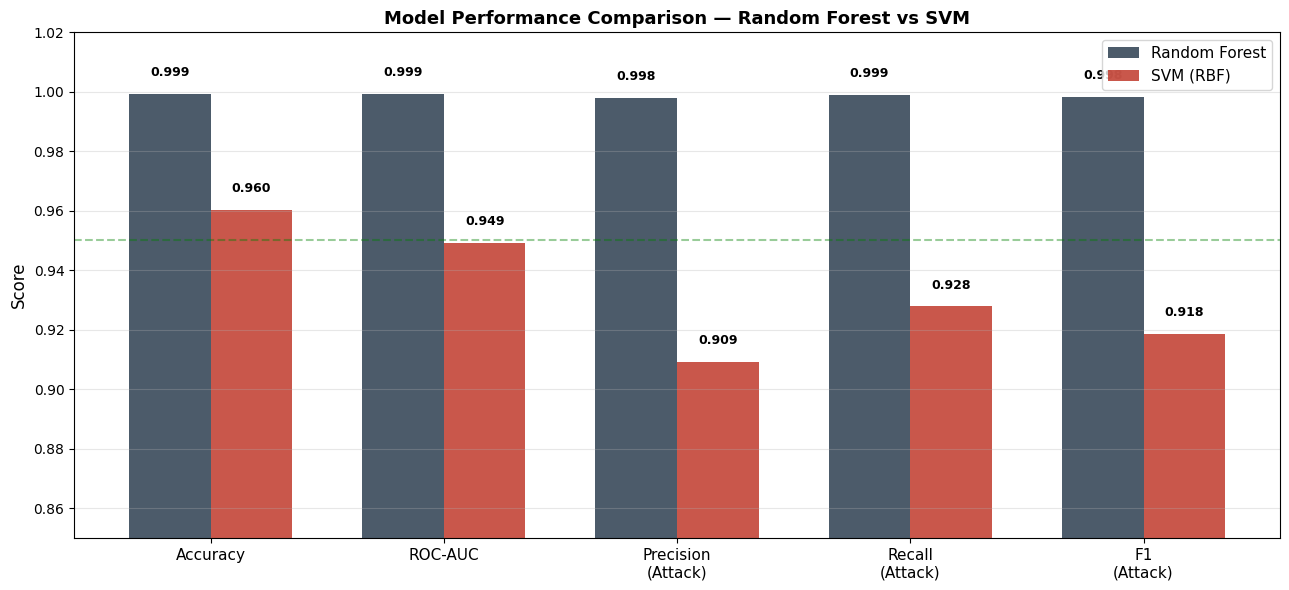

Saved


In [21]:
# Cell 17: Model comparison bar chart

metrics = ['Accuracy', 'ROC-AUC', 'Precision\n(Attack)',
           'Recall\n(Attack)', 'F1\n(Attack)']

from sklearn.metrics import precision_score, recall_score, f1_score

rf_scores = [
    accuracy_score(Y_test, rf_preds),
    roc_auc_score(Y_test, rf_preds),
    precision_score(Y_test, rf_preds),
    recall_score(Y_test, rf_preds),
    f1_score(Y_test, rf_preds)
]

svm_scores = [
    accuracy_score(Y_test, svm_preds),
    roc_auc_score(Y_test, svm_preds),
    precision_score(Y_test, svm_preds),
    recall_score(Y_test, svm_preds),
    f1_score(Y_test, svm_preds)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, rf_scores, width,
               label='Random Forest', color='#2c3e50', alpha=0.85)
bars2 = ax.bar(x + width/2, svm_scores, width,
               label='SVM (RBF)', color='#c0392b', alpha=0.85)

# Add value labels on bars
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_ylim(0.85, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Random Forest vs SVM',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.4, label='95% threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

In [23]:
# Cell 18: Save trained models
import joblib

SAVE_PATH = '/content/drive/MyDrive/EGR432/midterm_project/'

joblib.dump(rf_model, SAVE_PATH + 'random_forest_model.pkl')
joblib.dump(svm_model, SAVE_PATH + 'svm_model.pkl')
joblib.dump(scaler, SAVE_PATH + 'scaler.pkl')

print("Models saved to Google Drive!")
print(f"   → random_forest_model.pkl")
print(f"   → svm_model.pkl")
print(f"   → scaler.pkl  (needed to scale new data before predicting)")

Models saved to Google Drive!
   → random_forest_model.pkl
   → svm_model.pkl
   → scaler.pkl  (needed to scale new data before predicting)
